## Computing the Jacobian (Sensitivity Matrix)

`pytem_fwd.ipynb` established that pyTEM's 1-D forward models are accurate. In practice, however, recovering a resistivity model from TEM data requires solving an iterative least-squares problem. Each Gauss–Newton iteration requires the **Jacobian matrix** $\mathbf{J}$, where

$$J_{ij} = \frac{\partial \ln(-\dot{B}_i)}{\partial \ln \rho_j}$$

quantifies how the $i$-th datum changes when the $j$-th layer resistivity is perturbed.

The simplest Jacobian approximation is **finite difference (FD)**: perturb each layer in turn, re-run the forward model, and divide. For a 28-layer mesh this means **29 forward calls per Gauss–Newton iteration**, and a typical inversion converges in 5–10 iterations — 145–290 forward calls in total. Computation speed is therefore critical.

This notebook investigates three routes to a faster inversion:

1. **Transform filters** — different Digital Linear Filter (DLF) lengths and the Euler–Stehfest alternative trade accuracy against speed.
2. **Analytical Jacobian** — differentiating the Wait recursion directly yields all $N$ layer gradients from a single forward+backward pass, eliminating the $N$-fold cost of FD.
3. **Hardware acceleration** — Numba JIT (CPU) and CuPy (GPU) backends compile the inner loops for further order-of-magnitude speed gains.

In [1]:
import sys
import time
import importlib

import numpy as np
import matplotlib.pyplot as plt

sys.path.insert(0, r'C:\Users\pamcl\OneDrive - Danmarks Tekniske Universitet\Dokumenter\Projects\Python\pyTEM')

# Import the main pyTEM functions and constants
from pytem import (
    # Long-form names (used by other notebooks and the library internally)
    fwd_circle_central,
    fwd_circle_offset,
    fwd_square_central,
    fwd_square_offset,
    # Constants and flags
    MU0,
    HAS_NUMBA,
    HAS_CUDA,
    HANKEL_FILTERS,
    FOURIER_FILTERS,
    EULER_PARAMS,
)

# TE-mode recursion + gradient (used in analytical Jacobian section)
from pytem.recursion import te_reflection_coeff_grad

### Baseline: single forward-call runtime

Before optimising, let's measure how long a single forward model call takes for each of the four loop geometries supported by pyTEM. The model used throughout this notebook has 28 layers and 31 gate times, representative of a real survey.

| Geometry | Loop type | Rx position |
|----------|-----------|-------------|
| Circle-central | Circular Tx loop | Rx at loop centre |
| Circle-offset | Circular Tx loop | Rx offset from centre |
| Square-central | Square Tx loop | Rx at loop centre |
| Square-offset | Square Tx loop | Rx offset from centre |

The bar chart below shows median forward-call time per geometry. Even the fastest call costs several milliseconds; a 29-call FD Jacobian therefore takes hundreds of milliseconds per iteration, and a full inversion runs into tens of seconds — motivating the optimisations in the sections below.

Geometry                    Time [ms]
--------------------------------------
  Circle                        482.4
  Square Full                  2964.9
  Square Sym                   1779.7
  Circle (offset)               119.7
  Square (offset)             14420.9


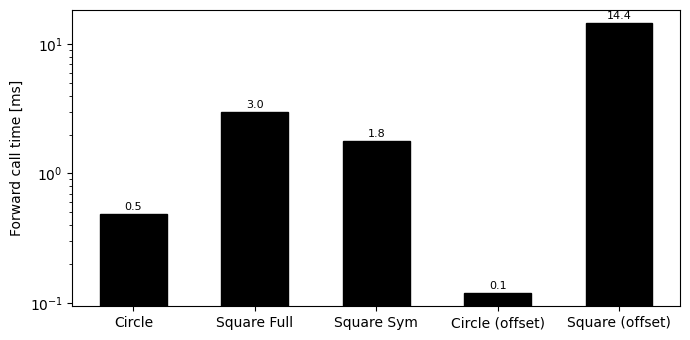

In [21]:

import timeit

# --- Benchmark model: 30 layers, 31 gate times ---
depths        = np.cumsum(np.geomspace(1.0, 12.0, 30))   # 30 cumulative depths [m]
thicknesses   = np.diff(depths)                            # 29 thicknesses
resistivities = np.ones(len(depths)) * 100.0               # 30 resistivities [Ω·m]
a             = np.sqrt(50.**2 / np.pi)                    # equivalent circle radius [m]
L             = np.sqrt(np.pi) * a                         # equal-area square side [m]
rx_offset     = 10.0                                       # offset receiver [m]
times         = np.logspace(-5, -2, 31)                    # 31 log-spaced gates

def benchmark(fn, n=1):
    """Median wall-time [s] over n single runs."""
    return np.median(timeit.repeat(fn, number=1, repeat=n))

geom_results = {}

geom_results['Circle'] = benchmark(lambda: fwd_circle_central(
    thicknesses, resistivities, a, times, hankel_filter='key_201'))

geom_results['Square\nFull'] = benchmark(lambda: fwd_square_central(
    thicknesses, resistivities, L, times, n_quad=5, use_symmetry=False, hankel_filter='key_201'))

geom_results['Square\nSym'] = benchmark(lambda: fwd_square_central(
    thicknesses, resistivities, L, times, n_quad=5, use_symmetry=True, hankel_filter='key_201'))

geom_results['Circle\n(offset)'] = benchmark(lambda: fwd_circle_offset(
    thicknesses, resistivities, a, rx_offset, times, hankel_filter='key_201'))

geom_results['Square\n(offset)'] = benchmark(lambda: fwd_square_offset(
    thicknesses, resistivities, L, rx_offset, 0.0, times, n_quad=11, hankel_filter='key_201'))

print(f"{'Geometry':25s}  {'Time [ms]':>10s}")
print("-" * 38)
for k, v in geom_results.items():
    print(f"  {k.replace(chr(10), ' '):23s}  {v * 1000:10.1f}")

# --- Bar chart ---
_labels_g = [k.replace('\n', ' ') for k in geom_results]
_vals_g   = [v for v in geom_results.values()]   # ms

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(_labels_g, _vals_g, color='k', edgecolor='black', width=0.55)
for bar, val in zip(bars, _vals_g):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.04,
            f"{val:.1f}", ha='center', va='bottom', fontsize=8)
ax.set_ylabel('Forward call time [ms]')
ax.set_yscale('log')
fig.tight_layout()
plt.show()


## 1. Transform Filters

The 1-D TEM forward model approximates the Hankel and Fourier transforms using **Digital Linear Filters (DLF)**. Two parameters control the accuracy–speed trade-off:

| Parameter | Options | Effect |
|-----------|---------|--------|
| Hankel filter | `key_101` (101 pts), `key_201` (201 pts) | Longer filters improve accuracy at the cost of more kernel evaluations |
| Fourier filter | `key_81` (81 pts), `key_101` (101 pts) | Same trade-off for the cosine/sine transform |

As an alternative to the Fourier DLF, the **Euler–Stehfest** method evaluates the inverse Laplace transform directly. Accuracy is controlled by the order (8, 11, 15, or 19 terms); higher orders are more accurate but require more kernel evaluations.

pyTEM implements both integral transforms as DLFs:

1. **Hankel transform** — converts the radial wavenumber kernel to the spatial domain. Two filter lengths are available: 101-point and 201-point (Key 2009).
2. **Fourier transform** — converts the frequency-domain result to the time domain. Two filter lengths are available: 81-point (Key 2009) and 101-point (Key 2012).

The cell below benchmarks every DLF combination and every Euler–Stehfest order using the NumPy backend, measuring both runtime and accuracy relative to the longest available DLF (201-pt Hankel, 101-pt Fourier).

In [ ]:
# Benchmark model: 28-layer inversion mesh, 50 m loop
# Same depths, gate count, and loop geometry as the actual inversion so
# the timing numbers reflect the true per-call cost.
n_reps   = 1

# Reference response: longest available DLF (201-pt Hankel, 101-pt Fourier)
_ref_response = fwd_circle_central(
    thicknesses=thicknesses, resistivities=resistivities,
    tx_radius=a, times=times,
    use_numba=False, use_cuda=False,
    transform='dlf', hankel_filter='key_201', fourier_filter='key_101',
)

filter_results   = {}   # median time [s]
accuracy_results = {}   # max relative error vs reference

print(f"{'Config':40s}  {'Time [ms]':>10s}  {'Max rel. error [%]':>14s}")
print("-" * 75)

print("DLF (Hankel × Fourier filter):")
for hf in HANKEL_FILTERS:
    for ff in FOURIER_FILTERS:
        label = f"DLF  H:{hf}  F:{ff}"
        resp = fwd_circle_central(
            thicknesses=thicknesses, resistivities=resistivities,
            tx_radius=a, times=times,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        )
        err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
        t = benchmark(lambda hf=hf, ff=ff: fwd_circle_central(
            thicknesses=thicknesses, resistivities=resistivities,
            tx_radius=a, times=times,
            use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter=hf, fourier_filter=ff,
        ))
        filter_results[label]   = t
        accuracy_results[label] = err
        ref_marker = "  ← reference" if (hf == 'key_201' and ff == 'key_101') else ""
        print(f"  {label:38s}  {t * 1000:10.2f}  {err * 100:14.3f}{ref_marker}")

print("\nEuler-Stehfest (varying order):")
for order in EULER_PARAMS:
    label = f"Euler  order={order}"
    resp = fwd_circle_central(
        thicknesses=thicknesses, resistivities=resistivities,
        tx_radius=a, times=times,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=order,
    )
    err = float(np.max(np.abs(resp - _ref_response) / np.abs(_ref_response)))
    t = benchmark(lambda o=order: fwd_circle_central(
        thicknesses=thicknesses, resistivities=resistivities,
        tx_radius=a, times=times,
        use_numba=False, use_cuda=False,
        transform='euler', euler_order=o,
    ))
    filter_results[label]   = t
    accuracy_results[label] = err
    print(f"  {label:38s}  {t * 1000:10.2f}  {err * 100:14.3f}")


Config                                     Time [ms]  Max rel. error [%]
---------------------------------------------------------------------------
DLF (Hankel × Fourier filter):
  DLF  H:key_201  F:key_101                  1702.56           0.000  ← reference
  DLF  H:key_201  F:key_81                   1441.38           0.044
  DLF  H:key_101  F:key_101                  1609.06           0.000
  DLF  H:key_101  F:key_81                    838.10           0.044

Euler-Stehfest (varying order):
  Euler  order=8                              243.33           0.191
  Euler  order=11                             386.95           0.040
  Euler  order=15                             420.08           0.041
  Euler  order=19                             510.62           0.041


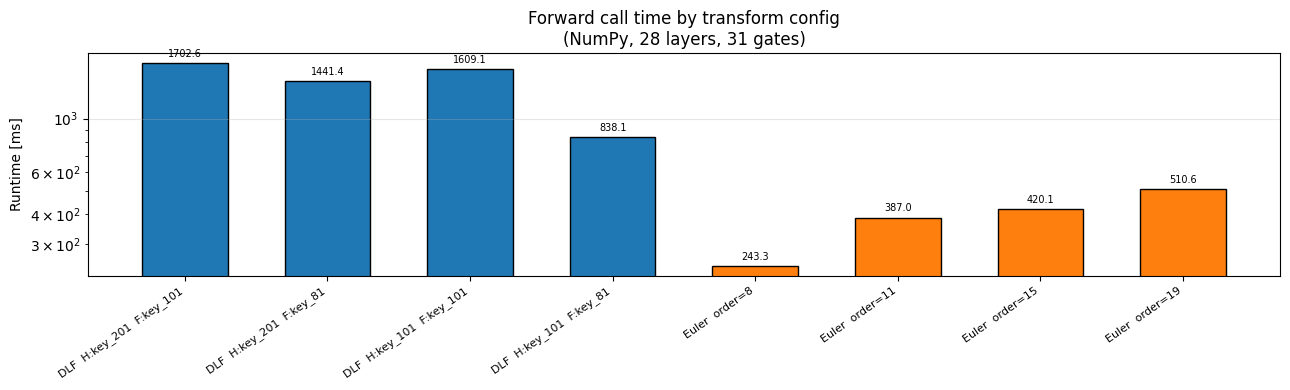

In [ ]:

# --- Bar chart: runtime by transform config ---
labels_p = list(filter_results.keys())
times_p  = [filter_results[k] * 1000 for k in labels_p]   # ms
x_p      = np.arange(len(labels_p))

fig, ax = plt.subplots(figsize=(13, 4))
bars = ax.bar(x_p, times_p, color='k', edgecolor='black', width=0.55)
for bar, val in zip(bars, times_p):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.04,
            f"{val:.1f}", ha='center', va='bottom', fontsize=7)
ax.set_xticks(x_p)
ax.set_xticklabels(labels_p, rotation=35, ha='right', fontsize=8)
ax.set_ylabel('Runtime [ms]')
ax.set_title('Forward call time by transform config\n(NumPy, 30 layers, 31 gates)')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()


The results show that the **101-pt Hankel / 81-pt Fourier DLF** combination is virtually indistinguishable from longer filter configurations in the time range of interest (max relative error well below 0.1 %), while running faster than the 201-pt Hankel variant. The Euler–Stehfest method at order 11 matches DLF accuracy and offers a similar runtime.

**All remaining sections use `hankel_filter='key_101'`, `fourier_filter='key_81'`** — the fastest configuration that retains full accuracy.

## 2. Jacobian

### 2.1 Finite Difference

Working in log-space (both data and model parameters log-transformed for numerical stability), the Jacobian is:

$$J_{ij} = \frac{\partial \ln(-\dot{B}_i)}{\partial \ln\rho_j}$$

The **forward finite difference** approximation perturbs each layer in turn:

$$J_{ij} \approx \frac{\ln\!\bigl(-\dot{B}_i(\mathbf{m} + \delta_j\mathbf{e}_j)\bigr) - \ln\!\bigl(-\dot{B}_i(\mathbf{m})\bigr)}{\delta_j}$$

where $\mathbf{e}_j$ is the $j$-th unit vector in log-resistivity space and the step size scales in log-space:

$$\delta_j = \varepsilon \cdot \max(1,\, |\ln\rho_j|), \qquad \varepsilon = 10^{-4}$$

**Cost.** One baseline evaluation $F(\mathbf{m})$ plus one perturbed evaluation per layer gives $N + 1$ forward calls per Jacobian. For a 28-layer mesh this means **29 forward calls per Gauss–Newton iteration**.

**Truncation error.** Approximately $10^{-4}$, negligible relative to typical data noise levels.

#### Implementation

In [19]:
def getJ(thicknesses, log_resistivities, tx_geom, times,
         use_numba=False, use_cuda=False, eps=1e-4, fwd=fwd_circle_central,
         transform='dlf', hankel_filter='key_101', fourier_filter='key_81',
         euler_order=11):
    """Finite-difference Jacobian  d(ln(-Ḃ_i)) / d(ln ρ_j).

    Evaluates N+1 forward calls: one baseline F(m) plus one perturbed call
    F(m + δ_j e_j) for each of the N layers. Step size is:

        δ_j = ε · max(1, |ln ρ_j|)

    so the perturbation is automatically scaled in log-resistivity space.

    Parameters
    ----------
    thicknesses       : (N-1,) layer thicknesses [m]
    log_resistivities : (N,)   ln(ρ_j)
    tx_geom           : float  transmitter equivalent radius [m]
    times             : (n_t,) gate times [s]
    use_numba         : bool   use Numba JIT backend (default False)
    use_cuda          : bool   use CuPy GPU backend (default False)
    eps               : float  finite-difference step size (default 1e-4)
    fwd               : callable  forward model function (default fwd_circle_central)
    transform         : 'dlf' or 'euler'
    hankel_filter     : str   (default 'key_101')
    fourier_filter    : str   (default 'key_81')
    euler_order       : int   (default 11)

    Returns
    -------
    J : (n_t, N) float64
    """
    fwd_kw = dict(use_numba=use_numba, use_cuda=use_cuda, transform=transform,
                  hankel_filter=hankel_filter, fourier_filter=fourier_filter,
                  euler_order=euler_order)
    f0 = -fwd(thicknesses=thicknesses, resistivities=np.exp(log_resistivities),
              tx_radius=tx_geom, times=times, **fwd_kw)
    J = np.zeros((f0.size, log_resistivities.size))
    for i in range(log_resistivities.size):
        pert = log_resistivities.copy()
        step = eps * max(1.0, abs(log_resistivities[i]))
        pert[i] += step
        fi = -fwd(thicknesses=thicknesses, resistivities=np.exp(pert),
                  tx_radius=tx_geom, times=times, **fwd_kw)
        valid = (f0 > 0) & (fi > 0)
        J[valid, i] = (np.log(fi[valid]) - np.log(f0[valid])) / step
    return J


In [20]:
# --- Inversion mesh: 28 log-spaced layers to 120 m ---
depths = np.array([1., 2.088, 3.272, 4.56, 5.962, 7.487, 9.147,
                   10.953, 12.918, 15.056, 17.382, 19.913, 22.667,
                   25.664, 28.925, 32.473, 36.334, 40.535, 45.106,
                   50.08 , 55.492, 61.381, 67.789, 74.762, 82.349,
                   90.604, 99.587, 109.361, 120.001])

thicknesses       = np.diff(depths)
log_resistivities = np.ones(len(thicknesses)) * np.log(100.0)  # homogeneous 100 Ohm.m
a                 = np.sqrt(50.**2 / np.pi)    # equivalent circle radius [m] for 50x50 m loop
L                 = 50.0                        # square loop side [m]
times             = np.logspace(-5, -2, 31)    # 31 log-spaced gate times

# --- Compute FD Jacobian (NumPy, DLF key_101 / key_81) ---
J_fd = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
            tx_geom=a, times=times, use_numba=False, use_cuda=False,
            transform='dlf', hankel_filter='key_101', fourier_filter='key_81')

print(f"J_fd shape:        {J_fd.shape}  (n_gates × n_layers)")
print(f"Non-zero entries:  {np.sum(J_fd != 0)} / {J_fd.size}")
print(f"Value range:       [{J_fd.min():.3f},  {J_fd.max():.3f}]")


J_fd shape:        (31, 28)  (n_gates × n_layers)
Non-zero entries:  868 / 868
Value range:       [-1.228,  0.041]


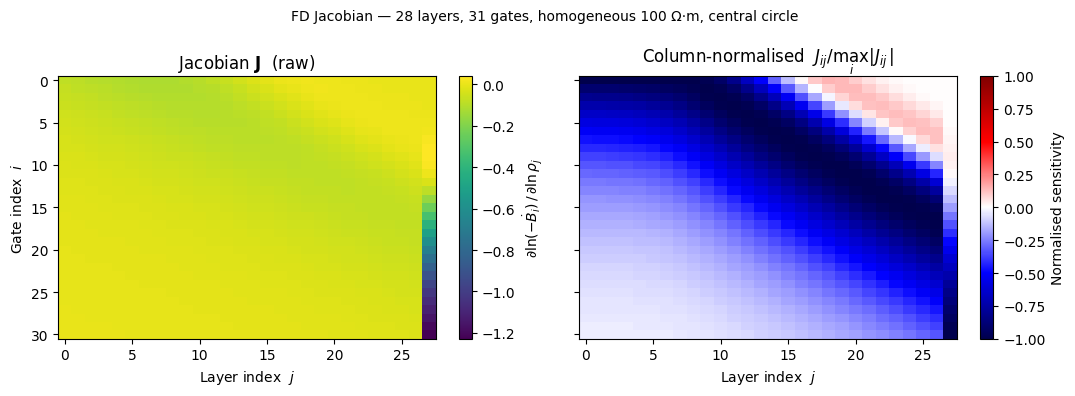

In [21]:
# --- Figure 1: raw Jacobian and column-normalised Jacobian ---
sens_norm = J_fd / np.maximum(np.abs(J_fd).max(axis=0, keepdims=True), 1e-30)

fig, axs = plt.subplots(1, 2, figsize=(11, 4), sharey=True)

im0 = axs[0].imshow(J_fd, aspect='auto', cmap='viridis')
plt.colorbar(im0, ax=axs[0]).set_label(
    r'$\partial\ln(-\dot{B}_i)\,/\,\partial\ln\rho_j$')
axs[0].set_title(r'Jacobian $\mathbf{J}$  (raw)')
axs[0].set_ylabel(r'Gate index  $i$')
axs[0].set_xlabel(r'Layer index  $j$')

im1 = axs[1].imshow(sens_norm, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
plt.colorbar(im1, ax=axs[1]).set_label('Normalised sensitivity')
axs[1].set_title(r'Column-normalised  $J_{ij}/\max_i|J_{ij}|$')
axs[1].set_xlabel(r'Layer index  $j$')

fig.suptitle(
    'FD Jacobian — 28 layers, 31 gates, homogeneous 100 Ω·m, central circle',
    fontsize=10)
fig.tight_layout()
plt.show()

# --- Figure 2: integrated sensitivity vs depth ---
# Exclude the half-space (last column) — it has no well-defined midpoint depth.
th_arr    = np.asarray(thicknesses)
depth_top = np.concatenate([[0.0], np.cumsum(th_arr)])
depth_mid = depth_top[:-1] + th_arr / 2.0   # shape (N,) midpoints of all N layers

cs = np.sqrt((J_fd[:, :-1] ** 2).sum(axis=0))   # L2 norm per finite layer (N-1,)




### 2.2 Analytical Jacobian

The FD approach above requires $N + 1$ forward calls per iteration. An **analytical Jacobian** obtained by differentiating the Wait recursion directly reduces this to a single forward+backward pass for all $N$ layers at once.

The TE-mode reflection coefficient $r_\mathrm{TE}(\lambda, \omega)$ is computed by the downward Wait recursion:

$$r_j = e^{-2\Gamma_j h_j}\,\frac{r_{j+1} + \psi_j}{1 + r_{j+1}\psi_j}, \qquad \psi_j = \frac{\Gamma_j - \Gamma_{j+1}}{\Gamma_j + \Gamma_{j+1}}, \qquad \Gamma_j = \sqrt{\lambda^2 + \frac{i\omega\mu_0}{\rho_j}}$$

where $h_j$ is layer thickness. Because $\Gamma_j$ depends on $\rho_j$ explicitly, the derivative $\partial r_\mathrm{TE}/\partial\ln\rho_j$ can be computed exactly via the chain rule.

**Forward + backward (adjoint) pass:**

1. **Forward pass (downward):** Run the Wait recursion as normal, but *store* $r_j$, $e^{-2\Gamma_j h_j}$, and $\psi_j$ at every interface.
2. **Backward pass (upward):** Propagate an adjoint variable $\bar{r}_j$ upward, accumulating $\partial r_\mathrm{TE}/\partial\ln\rho_j$ for each layer via:

$$\frac{\partial\Gamma_j}{\partial\ln\rho_j} = -\frac{i\omega\mu_0/\rho_j}{2\Gamma_j}, \qquad \frac{\partial r_j}{\partial\ln\rho_j} = \bar{r}_j \cdot \frac{\partial r_j}{\partial\Gamma_j} \cdot \frac{\partial\Gamma_j}{\partial\ln\rho_j}$$

The log-log Jacobian entry is then:

$$J_{ij} = \frac{\partial\ln(-\dot{B}_i)}{\partial\ln\rho_j} = -\frac{1}{-\dot{B}_i}\,\frac{\partial\dot{B}_i}{\partial\ln\rho_j}$$

**Cost comparison.** Both passes scale with $N 	imes K$, where $N$ is the number of layers and $K$ is the number of Hankel filter points. A single forward+backward pair yields gradients for **all $N$ layers simultaneously**, versus $N + 1$ separate forward passes for FD. For 28 layers the theoretical speedup is $\sim\!29\times$.

The implementation is provided by `getJ_analytical` in Section 3, which exposes NumPy, Numba JIT, and CuPy GPU backends via the `use_numba` and `use_cuda` flags.

## 3. Hardware Acceleration

The analytical Jacobian via the Wait recursion adjoint (`getJ_analytical`) and the FD Jacobian (`getJ`) both support three backends, selected by the `use_numba` and `use_cuda` flags:

| Backend | Flag | Description |
|---------|------|-------------|
| NumPy (default) | — | Vectorised Python, runs on any hardware |
| Numba JIT | `use_numba=True` | Compiles scalar inner loops to native code; fastest CPU option |
| CuPy (GPU) | `use_cuda=True` | Runs the forward+backward pass as GPU kernels; fastest on CUDA hardware |

The cells below implement the Numba and CuPy kernels, then define `getJ_analytical` as the unified public API that dispatches to the appropriate backend. Timing results and speedup factors are shown at the end of this section.

In [22]:

# ==============================================================================
# Numba JIT kernels for analytical Jacobian
# ==============================================================================
if HAS_NUMBA:
    import numba as nb
    _NB_OPTS = {'nogil': True, 'cache': True}

    @nb.njit(**_NB_OPTS)
    def _te_rte_grad_jit(lam, omega, thicknesses, resistivities, mu0):
        """Wait recursion + adjoint gradient (scalar loops, Numba JIT).
        Returns r_te (K,) and dr_te (N, K) = d(r_TE)/d(ln rho_j).
        """
        n_lay = len(resistivities)
        n_lam = len(lam)
        sval  = 1j * omega

        Gamma  = np.empty((n_lay, n_lam), dtype=np.complex128)
        dGamma = np.empty((n_lay, n_lam), dtype=np.complex128)
        for j in range(n_lay):
            sigma_j = 1.0 / resistivities[j]
            prod    = sval * mu0 * sigma_j
            for m in range(n_lam):
                g              = np.sqrt(lam[m]**2 + prod)
                Gamma[j, m]    = g
                dGamma[j, m]   = -prod / (2.0 * g)

        r_store   = np.zeros((n_lay, n_lam), dtype=np.complex128)
        exp_store = np.zeros((n_lay - 1, n_lam), dtype=np.complex128)
        r = np.zeros(n_lam, dtype=np.complex128)
        r_store[n_lay - 1] = r

        for j in range(n_lay - 2, -1, -1):
            h     = thicknesses[j]
            r_new = np.empty(n_lam, dtype=np.complex128)
            for m in range(n_lam):
                ej              = np.exp(-2.0 * Gamma[j, m] * h)
                exp_store[j, m] = ej
                psi             = (Gamma[j, m] - Gamma[j+1, m]) / (Gamma[j, m] + Gamma[j+1, m])
                r_new[m]        = ej * (r[m] + psi) / (1.0 + r[m] * psi)
            r = r_new
            r_store[j] = r

        r_te    = np.empty(n_lam, dtype=np.complex128)
        psi_air = np.empty(n_lam, dtype=np.complex128)
        for m in range(n_lam):
            pa         = (lam[m] - Gamma[0, m]) / (lam[m] + Gamma[0, m])
            psi_air[m] = pa
            r_te[m]    = (r_store[0, m] + pa) / (1.0 + r_store[0, m] * pa)

        dr_te = np.zeros((n_lay, n_lam), dtype=np.complex128)
        adj   = np.empty(n_lam, dtype=np.complex128)
        for m in range(n_lam):
            pa        = psi_air[m]
            r0        = r_store[0, m]
            d_air     = 1.0 + r0 * pa
            adj[m]    = (1.0 - pa**2)  / d_air**2
            dpsi_dphi = (1.0 - r0**2)  / d_air**2
            dpsi_dG0  = -2.0 * lam[m] / (lam[m] + Gamma[0, m])**2
            dr_te[0, m] += dpsi_dphi * dpsi_dG0 * dGamma[0, m]

        for j in range(n_lay - 1):
            for m in range(n_lam):
                rb   = r_store[j+1, m];  ej   = exp_store[j, m]
                Gj   = Gamma[j, m];      Gjp1 = Gamma[j+1, m]
                sG   = Gj + Gjp1;        psi  = (Gj - Gjp1) / sG
                num  = rb + psi;          den  = 1.0 + rb * psi
                dpsi_dGj   =  2.0 * Gjp1 / sG**2
                dpsi_dGjp1 = -2.0 * Gj   / sG**2
                dr_dpsi    = ej * (1.0 - rb**2) / den**2
                dr_dGj     = (-2.0 * thicknesses[j] * ej) * num / den + dr_dpsi * dpsi_dGj
                dr_dGjp1   = dr_dpsi * dpsi_dGjp1
                dr_drbelow = ej * (1.0 - psi**2) / den**2
                dr_te[j,   m] += adj[m] * dr_dGj   * dGamma[j,   m]
                dr_te[j+1, m] += adj[m] * dr_dGjp1 * dGamma[j+1, m]
                adj[m] = adj[m] * dr_drbelow

        return r_te, dr_te

    @nb.njit(**_NB_OPTS)
    def _tem_circular_grad_jit(times, thicknesses, resistivities,
                               lam, lam_hj1, mu0, fourier_base, fourier_weights):
        """dBz/dt and analytical Jacobian via adjoint Wait recursion (Numba JIT, DLF).
        Returns dbdt (n_t,) and J_raw (n_t, N) before log-log conversion.
        Works for both circle_central and circle_offset — only lam_hj1 differs.
        """
        n_t = len(times);  n_f = len(fourier_base)
        n_lam = len(lam);  n_lay = len(resistivities)
        dbdt  = np.zeros(n_t)
        J_raw = np.zeros((n_t, n_lay))
        for i in range(n_t):
            t = times[i];  hz_acc = 0.0;  dhz_acc = np.zeros(n_lay)
            for k in range(n_f):
                omega = fourier_base[k] / t
                r_te, dr_te = _te_rte_grad_jit(lam, omega, thicknesses, resistivities, mu0)
                hz_c = 0.0 + 0.0j
                for m in range(n_lam):
                    hz_c += r_te[m] * lam_hj1[m]
                hz_c  *= 0.5
                hz_acc += mu0 * hz_c.imag * fourier_weights[k]
                for j in range(n_lay):
                    dhz_c = 0.0 + 0.0j
                    for m in range(n_lam):
                        dhz_c += dr_te[j, m] * lam_hj1[m]
                    dhz_c      *= 0.5
                    dhz_acc[j] += mu0 * dhz_c.imag * fourier_weights[k]
            dbdt[i]     = hz_acc  / t
            J_raw[i, :] = dhz_acc / t
        return dbdt, J_raw

    @nb.njit(**_NB_OPTS)
    def _tem_square_grad_jit(times, thicknesses, resistivities,
                             rho_q, area_w, quad_scale,
                             h_base, h_j0, mu0, fourier_base, fourier_weights):
        """Square-loop dBz/dt and analytical Jacobian (Numba JIT, DLF).
        Returns dbdt (n_t,) and J_raw (n_t, N) before log-log conversion.
        Works for both square_central and square_offset.
        """
        n_t   = len(times)
        n_f   = len(fourier_base)
        n_q   = len(rho_q)
        n_lam = len(h_base)
        n_lay = len(resistivities)
        _4pi  = 4.0 * np.pi

        dbdt  = np.zeros(n_t)
        J_raw = np.zeros((n_t, n_lay))

        lam_q  = np.empty(n_lam, dtype=np.float64)
        kern_q = np.empty(n_lam, dtype=np.float64)

        for i in range(n_t):
            t       = times[i]
            hz_acc  = 0.0
            dhz_acc = np.zeros(n_lay)

            for k in range(n_f):
                omega = fourier_base[k] / t
                hz_f  = 0.0 + 0.0j
                dhz_f = np.zeros(n_lay, dtype=np.complex128)

                for q in range(n_q):
                    rq = rho_q[q]
                    wq = area_w[q]
                    for m in range(n_lam):
                        lm        = h_base[m] / rq
                        lam_q[m]  = lm
                        kern_q[m] = lm * lm * h_j0[m] / (rq * _4pi)

                    r_te_q, dr_te_q = _te_rte_grad_jit(
                        lam_q, omega, thicknesses, resistivities, mu0)

                    hz_c = 0.0 + 0.0j
                    for m in range(n_lam):
                        hz_c += r_te_q[m] * kern_q[m]
                    hz_f += wq * hz_c

                    for j in range(n_lay):
                        dhz_c = 0.0 + 0.0j
                        for m in range(n_lam):
                            dhz_c += dr_te_q[j, m] * kern_q[m]
                        dhz_f[j] += wq * dhz_c

                hz_acc += mu0 * (hz_f * quad_scale).imag * fourier_weights[k]
                for j in range(n_lay):
                    dhz_acc[j] += mu0 * (dhz_f[j] * quad_scale).imag * fourier_weights[k]

            dbdt[i]     = hz_acc  / t
            J_raw[i, :] = dhz_acc / t

        return dbdt, J_raw

    # ------ Euler variants of the above (complex Bromwich frequencies) ------

    @nb.njit(**_NB_OPTS)
    def _tem_circular_grad_euler_jit(times, thicknesses, resistivities,
                                     lam, lam_hj1, mu0, e_eta, e_A):
        """Circle analytical Jacobian via adjoint Wait recursion (Euler–Stehfest, Numba JIT).
        Returns dbdt (n_t,) and J_raw (n_t, N) with step-off scaling applied.
        omega_k = k*pi/t - (A/2t)*1j  is complex; _te_rte_grad_jit handles it natively.
        """
        n_t   = len(times)
        n_eval = len(e_eta)
        n_lam = len(lam)
        n_lay = len(resistivities)
        dbdt  = np.zeros(n_t)
        J_raw = np.zeros((n_t, n_lay))
        for i in range(n_t):
            t      = times[i]
            c      = e_A / (2.0 * t)
            h_step = np.pi / t
            hz_acc  = 0.0
            dhz_acc = np.zeros(n_lay)
            for k in range(n_eval):
                omega  = k * h_step - c * 1j          # complex Bromwich frequency
                sign_k = (-1.0)**k * e_eta[k]
                r_te, dr_te = _te_rte_grad_jit(lam, omega, thicknesses, resistivities, mu0)
                hz_c = 0.0 + 0.0j
                for m in range(n_lam):
                    hz_c += r_te[m] * lam_hj1[m]
                hz_c *= 0.5
                hz_acc += sign_k * mu0 * hz_c.real
                for j in range(n_lay):
                    dhz_c = 0.0 + 0.0j
                    for m in range(n_lam):
                        dhz_c += dr_te[j, m] * lam_hj1[m]
                    dhz_c *= 0.5
                    dhz_acc[j] += sign_k * mu0 * dhz_c.real
            prefac      = np.exp(e_A / 2.0) / t
            dbdt[i]     = -prefac * hz_acc    # -1 for step-off (signal = -1)
            J_raw[i, :] = -prefac * dhz_acc
        return dbdt, J_raw

    @nb.njit(**_NB_OPTS)
    def _tem_square_grad_euler_jit(times, thicknesses, resistivities,
                                   rho_q, area_w, quad_scale,
                                   h_base, h_j0, mu0, e_eta, e_A):
        """Square analytical Jacobian via adjoint Wait recursion (Euler–Stehfest, Numba JIT).
        Returns dbdt (n_t,) and J_raw (n_t, N) with step-off scaling applied.
        """
        n_t    = len(times)
        n_eval = len(e_eta)
        n_q    = len(rho_q)
        n_lam  = len(h_base)
        n_lay  = len(resistivities)
        _4pi   = 4.0 * np.pi
        dbdt   = np.zeros(n_t)
        J_raw  = np.zeros((n_t, n_lay))
        lam_q  = np.empty(n_lam, dtype=np.float64)
        kern_q = np.empty(n_lam, dtype=np.float64)
        for i in range(n_t):
            t      = times[i]
            c      = e_A / (2.0 * t)
            h_step = np.pi / t
            hz_acc  = 0.0
            dhz_acc = np.zeros(n_lay)
            for k in range(n_eval):
                omega  = k * h_step - c * 1j
                sign_k = (-1.0)**k * e_eta[k]
                hz_f  = 0.0 + 0.0j
                dhz_f = np.zeros(n_lay, dtype=np.complex128)
                for q in range(n_q):
                    rq = rho_q[q];  wq = area_w[q]
                    for m in range(n_lam):
                        lm        = h_base[m] / rq
                        lam_q[m]  = lm
                        kern_q[m] = lm * lm * h_j0[m] / (rq * _4pi)
                    r_te_q, dr_te_q = _te_rte_grad_jit(
                        lam_q, omega, thicknesses, resistivities, mu0)
                    hz_c = 0.0 + 0.0j
                    for m in range(n_lam):
                        hz_c += r_te_q[m] * kern_q[m]
                    hz_f += wq * hz_c
                    for j in range(n_lay):
                        dhz_c = 0.0 + 0.0j
                        for m in range(n_lam):
                            dhz_c += dr_te_q[j, m] * kern_q[m]
                        dhz_f[j] += wq * dhz_c
                hz_acc  += sign_k * mu0 * (hz_f  * quad_scale).real
                for j in range(n_lay):
                    dhz_acc[j] += sign_k * mu0 * (dhz_f[j] * quad_scale).real
            prefac      = np.exp(e_A / 2.0) / t
            dbdt[i]     = -prefac * hz_acc
            J_raw[i, :] = -prefac * dhz_acc
        return dbdt, J_raw

# ==============================================================================
# CuPy GPU kernels for analytical Jacobian
# ==============================================================================
if HAS_CUDA:
    import cupy as cp

    def _te_reflection_coeff_grad_gpu(d_lam, omega_2d, d_thicknesses, d_resistivities):
        n_lay    = len(d_resistivities)
        n_t, n_f = omega_2d.shape
        sval    = 1j * omega_2d[:, :, None]
        d_sigma = 1.0 / d_resistivities
        Gamma   = cp.empty((n_lay, n_t, n_f, len(d_lam)), dtype=cp.complex128)
        for j in range(n_lay):
            Gamma[j] = cp.sqrt(d_lam[None, None, :]**2 + sval * MU0 * float(d_sigma[j]))
        sval_4d       = 1j * omega_2d[None, :, :, None]
        dGamma_dlnrho = (-sval_4d * MU0 * d_sigma[:, None, None, None] / (2.0 * Gamma))
        r_store   = cp.zeros((n_lay, n_t, n_f, len(d_lam)), dtype=cp.complex128)
        exp_store = cp.zeros((n_lay - 1, n_t, n_f, len(d_lam)), dtype=cp.complex128)
        r = cp.zeros((n_t, n_f, len(d_lam)), dtype=cp.complex128)
        r_store[n_lay - 1] = r
        for j in range(n_lay - 2, -1, -1):
            psi          = (Gamma[j] - Gamma[j+1]) / (Gamma[j] + Gamma[j+1])
            exp_j        = cp.exp(-2.0 * Gamma[j] * d_thicknesses[j])
            exp_store[j] = exp_j
            r            = exp_j * (r + psi) / (1.0 + r * psi)
            r_store[j]   = r
        psi_air = (d_lam[None, None, :] - Gamma[0]) / (d_lam[None, None, :] + Gamma[0])
        r_TE    = (r_store[0] + psi_air) / (1.0 + r_store[0] * psi_air)
        denom_air      = 1.0 + r_store[0] * psi_air
        dr_TE_dr0      = (1.0 - psi_air**2)    / denom_air**2
        dr_TE_dpsi_air = (1.0 - r_store[0]**2) / denom_air**2
        dpsi_air_dG0   = (-2.0 * d_lam[None, None, :] / (d_lam[None, None, :] + Gamma[0])**2)
        dr_TE_all = cp.zeros((n_lay, n_t, n_f, len(d_lam)), dtype=cp.complex128)
        dr_TE_all[0] += dr_TE_dpsi_air * dpsi_air_dG0 * dGamma_dlnrho[0]
        adj = dr_TE_dr0.copy()
        for j in range(n_lay - 1):
            r_below    = r_store[j+1];  exp_j      = exp_store[j]
            psi_j      = (Gamma[j] - Gamma[j+1]) / (Gamma[j] + Gamma[j+1])
            numer      = r_below + psi_j;  denom = 1.0 + r_below * psi_j
            dpsi_dGj   =  2.0 * Gamma[j+1] / (Gamma[j] + Gamma[j+1])**2
            dpsi_dGjp1 = -2.0 * Gamma[j]   / (Gamma[j] + Gamma[j+1])**2
            dr_dpsi    = exp_j * (1.0 - r_below**2) / denom**2
            dr_dGj     = -2.0 * d_thicknesses[j] * exp_j * numer / denom + dr_dpsi * dpsi_dGj
            dr_dGjp1   = dr_dpsi * dpsi_dGjp1
            dr_drbelow = exp_j * (1.0 - psi_j**2) / denom**2
            dr_TE_all[j]   += adj * dr_dGj   * dGamma_dlnrho[j]
            dr_TE_all[j+1] += adj * dr_dGjp1 * dGamma_dlnrho[j+1]
            adj = adj * dr_drbelow
        return r_TE, dr_TE_all

    def _tem_circular_grad_gpu(times, thicknesses, resistivities, tx_radius,
                               lam_hj1, d_h_base, d_f_base, d_f_sin):
        d_times = cp.asarray(times);  d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho   = cp.asarray(resistivities, dtype=cp.float64)
        d_lam   = d_h_base / float(tx_radius)
        d_lam_hj1 = cp.asarray(lam_hj1)
        omega_2d  = d_f_base[None, :] / d_times[:, None]
        r_te, dr_te = _te_reflection_coeff_grad_gpu(d_lam, omega_2d, d_thick, d_rho)
        hz  = 0.5 * cp.sum(r_te  * d_lam_hj1[None, None, :],          axis=2)
        dhz = 0.5 * cp.sum(dr_te * d_lam_hj1[None, None, None, :], axis=3)
        sig  = MU0 * hz.imag;   dsig = MU0 * dhz.imag
        dbdt  = cp.sum(sig  * d_f_sin[None, :],          axis=1) / d_times
        J_raw = (cp.sum(dsig * d_f_sin[None, None, :], axis=2) / d_times[None, :]).T
        return cp.asnumpy(dbdt), cp.asnumpy(J_raw)

    def _tem_square_grad_gpu(times, thicknesses, resistivities,
                             rho_q, area_w, quad_scale,
                             d_h_base, d_h_j0, d_f_base, d_f_sin):
        """Square-loop analytical Jacobian on GPU (DLF).
        Loops over n_q quadrature points; each iteration runs the full
        (n_t, n_f, n_lam) adjoint on the GPU then accumulates with area weight.
        """
        d_times  = cp.asarray(times)
        d_thick  = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho    = cp.asarray(resistivities, dtype=cp.float64)
        n_t      = len(times)
        n_lay    = len(resistivities)
        omega_2d = d_f_base[None, :] / d_times[:, None]
        _4pi     = 4.0 * np.pi
        d_dbdt   = cp.zeros(n_t,          dtype=cp.float64)
        d_Jraw   = cp.zeros((n_t, n_lay), dtype=cp.float64)
        for q in range(len(rho_q)):
            rq       = float(rho_q[q]);  wq = float(area_w[q])
            d_lam_q  = d_h_base / rq
            d_kern_q = d_lam_q**2 * d_h_j0 / (rq * _4pi)
            r_te, dr_te = _te_reflection_coeff_grad_gpu(
                d_lam_q, omega_2d, d_thick, d_rho)
            # r_te:  (n_t, n_f, n_lam)
            # dr_te: (n_lay, n_t, n_f, n_lam)
            hz  = cp.sum(r_te  * d_kern_q[None, None, :],          axis=2)   # (n_t, n_f)
            dhz = cp.sum(dr_te * d_kern_q[None, None, None, :], axis=3)   # (n_lay, n_t, n_f)
            sig  = MU0 * hz.imag    # (n_t, n_f)
            dsig = MU0 * dhz.imag   # (n_lay, n_t, n_f)
            d_dbdt += wq * cp.sum(sig  * d_f_sin[None, :],          axis=1) / d_times
            d_Jraw += wq * (cp.sum(dsig * d_f_sin[None, None, :], axis=2) / d_times[None, :]).T
        d_dbdt *= quad_scale
        d_Jraw *= quad_scale
        return cp.asnumpy(d_dbdt), cp.asnumpy(d_Jraw)

    # ------ Euler variants (complex Bromwich frequencies, same GPU adjoint) ------

    def _tem_circular_grad_euler_gpu(times, thicknesses, resistivities, tx_radius,
                                     lam_hj1, d_h_base, e_eta, e_A):
        """Circle analytical Jacobian on GPU (Euler–Stehfest).
        _te_reflection_coeff_grad_gpu already handles complex omega_2d natively.
        """
        d_times   = cp.asarray(times);  d_thick = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho     = cp.asarray(resistivities, dtype=cp.float64)
        d_lam     = d_h_base / float(tx_radius)
        d_lam_hj1 = cp.asarray(lam_hj1)
        n_eval    = len(e_eta)
        k_arr     = cp.arange(n_eval, dtype=cp.float64)
        c_vals    = float(e_A) / (2.0 * d_times)                             # (n_t,)
        h_vals    = cp.full(len(times), np.pi) / d_times                     # (n_t,)
        omega_2d  = k_arr[None, :] * h_vals[:, None] - c_vals[:, None] * 1j  # (n_t, n_eval), complex
        r_te, dr_te = _te_reflection_coeff_grad_gpu(d_lam, omega_2d, d_thick, d_rho)
        hz  = 0.5 * cp.sum(r_te  * d_lam_hj1[None, None, :],          axis=2)     # (n_t, n_eval)
        dhz = 0.5 * cp.sum(dr_te * d_lam_hj1[None, None, None, :], axis=3)        # (n_lay, n_t, n_eval)
        signs_k = cp.asarray((-1.0)**np.arange(n_eval) * e_eta)                   # (n_eval,)
        hz_acc  = MU0 * cp.sum(signs_k[None, :] * hz.real, axis=1)                # (n_t,)
        dhz_acc = MU0 * cp.sum(signs_k[None, None, :] * dhz.real, axis=2)         # (n_lay, n_t)
        prefac  = cp.exp(float(e_A) / 2.0) / d_times                              # (n_t,)
        dbdt    = -prefac * hz_acc                                                  # step-off
        J_raw   = (-prefac[None, :] * dhz_acc).T
        return cp.asnumpy(dbdt), cp.asnumpy(J_raw)

    def _tem_square_grad_euler_gpu(times, thicknesses, resistivities,
                                   rho_q, area_w, quad_scale,
                                   d_h_base, d_h_j0, e_eta, e_A):
        """Square analytical Jacobian on GPU (Euler–Stehfest)."""
        d_times  = cp.asarray(times)
        d_thick  = cp.asarray(thicknesses, dtype=cp.float64)
        d_rho    = cp.asarray(resistivities, dtype=cp.float64)
        n_t      = len(times)
        n_lay    = len(resistivities)
        n_eval   = len(e_eta)
        _4pi     = 4.0 * np.pi
        k_arr    = cp.arange(n_eval, dtype=cp.float64)
        c_vals   = float(e_A) / (2.0 * d_times)
        h_vals   = cp.full(n_t, np.pi) / d_times
        omega_2d = k_arr[None, :] * h_vals[:, None] - c_vals[:, None] * 1j  # (n_t, n_eval)
        signs_k  = cp.asarray((-1.0)**np.arange(n_eval) * e_eta)
        d_hz_acc  = cp.zeros(n_t,          dtype=cp.float64)
        d_dhz_acc = cp.zeros((n_t, n_lay), dtype=cp.float64)
        for q in range(len(rho_q)):
            rq       = float(rho_q[q]);  wq = float(area_w[q])
            d_lam_q  = d_h_base / rq
            d_kern_q = d_lam_q**2 * d_h_j0 / (rq * _4pi)
            r_te, dr_te = _te_reflection_coeff_grad_gpu(d_lam_q, omega_2d, d_thick, d_rho)
            # r_te: (n_t, n_eval, n_lam), dr_te: (n_lay, n_t, n_eval, n_lam)
            hz  = cp.sum(r_te  * d_kern_q[None, None, :],          axis=2)   # (n_t, n_eval)
            dhz = cp.sum(dr_te * d_kern_q[None, None, None, :], axis=3)      # (n_lay, n_t, n_eval)
            d_hz_acc  += wq * MU0 * cp.sum(signs_k[None, :] * hz.real, axis=1)
            d_dhz_acc += wq * (MU0 * cp.sum(signs_k[None, None, :] * dhz.real, axis=2)).T
        d_hz_acc  *= quad_scale;  d_dhz_acc *= quad_scale
        prefac     = cp.exp(float(e_A) / 2.0) / d_times
        d_dbdt     = -prefac * d_hz_acc
        d_Jraw     = -(prefac[:, None] * d_dhz_acc)
        return cp.asnumpy(d_dbdt), cp.asnumpy(d_Jraw)


# ==============================================================================
# Analytical Jacobian: getJ_analytical  (all four loop geometries, DLF + Euler)
# ==============================================================================
def getJ_analytical(thicknesses, log_resistivities, tx_geom, times,
                    geometry='circle_central',
                    rx_offset=0.0, rx_y=0.0, n_quad=5, use_symmetry=True,
                    use_numba=False, use_cuda=False,
                    transform='dlf', hankel_filter='key_101',
                    fourier_filter='key_81', euler_order=11):
    """Analytical Jacobian  d(ln(-dBdt_i)) / d(ln rho_j)  for all loop geometries.

    Uses the adjoint Wait recursion: a single forward+backward pass per
    quadrature frequency yields gradients for all N layers simultaneously.

    Transform modes
    ---------------
    'dlf'   — Digital Linear Filter Fourier transform (default). Use
              `hankel_filter` and `fourier_filter` to select coefficients.
    'euler' — Euler–Stehfest inverse Laplace transform. Uses complex
              Bromwich-line frequencies; accuracy controlled by `euler_order`
              (8, 11, 15, or 19 terms). All backends (NumPy/Numba/CUDA)
              supported via the same adjoint recursion as the DLF path.

    Supported geometries (all support Numba and CUDA backends)
    --------------------
    'circle_central'  — Rx at centre of circular Tx loop (default)
    'circle_offset'   — Rx at radial offset `rx_offset` from circular Tx
    'square_central'  — Rx at centre of square Tx loop
    'square_offset'   — Rx at (rx_offset, rx_y) offset from square Tx centre

    Parameters
    ----------
    thicknesses       : (N-1,) layer thicknesses [m]
    log_resistivities : (N,)   ln(rho_j)
    tx_geom           : float  equivalent circle radius [m]
                               (side_length = tx_geom * sqrt(pi) for square loops)
    times             : (n_t,) gate times [s]
    geometry          : str    loop geometry (see above, default 'circle_central')
    rx_offset         : float  receiver radial offset or x-offset [m] (default 0.0)
    rx_y              : float  receiver y-offset for square_offset [m] (default 0.0)
    n_quad            : int    Gauss-Legendre order for square geometries (default 5)
    use_symmetry      : bool   use x<->y symmetry for square_central (default True)
    use_numba         : bool   Numba JIT backend (default False)
    use_cuda          : bool   CuPy GPU backend  (default False)
    transform         : 'dlf' or 'euler'  (default 'dlf')
    hankel_filter     : str    (default 'key_101')  — always used
    fourier_filter    : str    (default 'key_81')   — used only when transform='dlf'
    euler_order       : int    8, 11, 15, or 19 (default 11) — used only when transform='euler'

    Returns
    -------
    J : (n_t, N) float64
    """
    from scipy.special import j0 as _j0

    thicknesses   = np.asarray(thicknesses, dtype=float)
    resistivities = np.exp(np.asarray(log_resistivities, dtype=float))
    times         = np.asarray(times, dtype=float)
    a             = float(tx_geom)
    n_lay         = len(resistivities)
    n_t           = len(times)

    h_base, h_j0, h_j1 = HANKEL_FILTERS[hankel_filter]

    _use_euler = (transform == 'euler')
    if _use_euler:
        e_eta, e_A = EULER_PARAMS[euler_order]
    else:
        f_base, f_sin, _ = FOURIER_FILTERS[fourier_filter]

    # ---- Geometry-specific pre-computation ----
    _is_circle = geometry in ('circle_central', 'circle_offset')

    if geometry == 'circle_central':
        lam      = h_base / a
        lam_kern = lam * h_j1

    elif geometry == 'circle_offset':
        lam      = h_base / a
        j0_vals  = _j0(lam * float(rx_offset))
        lam_kern = lam * j0_vals * h_j1

    elif geometry == 'square_central':
        side  = a * np.sqrt(np.pi)
        hs    = side / 2.0
        gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
        x_pts = hs / 2.0 * (1.0 + gl_nodes)
        w_pts = gl_weights * hs / 2.0
        if use_symmetry:
            rho_q_l, area_w_l = [], []
            for _i in range(n_quad):
                for _jj in range(_i, n_quad):
                    w = w_pts[_i] * w_pts[_jj]
                    if _i != _jj:
                        w *= 2.0
                    rho_q_l.append(np.sqrt(x_pts[_i]**2 + x_pts[_jj]**2))
                    area_w_l.append(w)
            rho_q  = np.array(rho_q_l)
            area_w = np.array(area_w_l)
        else:
            _xx, _yy = np.meshgrid(x_pts, x_pts)
            _wx, _wy = np.meshgrid(w_pts, w_pts)
            rho_q  = np.sqrt(_xx.ravel()**2 + _yy.ravel()**2)
            area_w = (_wx * _wy).ravel()
        quad_scale = 4.0

    elif geometry == 'square_offset':
        side  = a * np.sqrt(np.pi)
        hs    = side / 2.0
        gl_nodes, gl_weights = np.polynomial.legendre.leggauss(n_quad)
        x_pts = hs * gl_nodes
        wx    = hs * gl_weights
        _xx, _yy = np.meshgrid(x_pts, x_pts, indexing='xy')
        _wx, _wy = np.meshgrid(wx, wx, indexing='xy')
        rho_q  = np.sqrt((_xx.ravel() - float(rx_offset))**2 +
                         (_yy.ravel() - float(rx_y))**2)
        rho_q  = np.maximum(rho_q, 1e-6)
        area_w = (_wx * _wy).ravel()
        quad_scale = 1.0

    else:
        raise ValueError(
            f"Unknown geometry '{geometry}'. Choose from: "
            "'circle_central', 'circle_offset', 'square_central', 'square_offset'.")

    # ---- Backend dispatch ----
    _use_nb  = HAS_NUMBA and use_numba
    _use_gpu = HAS_CUDA  and use_cuda and not _use_nb

    if _use_nb:
        if _use_euler:
            if _is_circle:
                dbdt, J_raw = _tem_circular_grad_euler_jit(
                    times, thicknesses, resistivities, lam, lam_kern, MU0, e_eta, e_A)
            else:
                dbdt, J_raw = _tem_square_grad_euler_jit(
                    times, thicknesses, resistivities,
                    rho_q, area_w, float(quad_scale),
                    h_base, h_j0, MU0, e_eta, e_A)
        else:
            if _is_circle:
                dbdt, J_raw = _tem_circular_grad_jit(
                    times, thicknesses, resistivities, lam, lam_kern, MU0, f_base, f_sin)
            else:
                dbdt, J_raw = _tem_square_grad_jit(
                    times, thicknesses, resistivities,
                    rho_q, area_w, float(quad_scale),
                    h_base, h_j0, MU0, f_base, f_sin)

    elif _use_gpu:
        d_h_base = cp.asarray(h_base)
        if _use_euler:
            if _is_circle:
                dbdt, J_raw = _tem_circular_grad_euler_gpu(
                    times, thicknesses, resistivities, a, lam_kern,
                    d_h_base, e_eta, e_A)
            else:
                d_h_j0 = cp.asarray(h_j0)
                dbdt, J_raw = _tem_square_grad_euler_gpu(
                    times, thicknesses, resistivities,
                    rho_q, area_w, float(quad_scale),
                    d_h_base, d_h_j0, e_eta, e_A)
        else:
            d_f_base = cp.asarray(f_base)
            d_f_sin  = cp.asarray(f_sin)
            if _is_circle:
                dbdt, J_raw = _tem_circular_grad_gpu(
                    times, thicknesses, resistivities, a, lam_kern,
                    d_h_base, d_f_base, d_f_sin)
            else:
                d_h_j0 = cp.asarray(h_j0)
                dbdt, J_raw = _tem_square_grad_gpu(
                    times, thicknesses, resistivities,
                    rho_q, area_w, float(quad_scale),
                    d_h_base, d_h_j0, d_f_base, d_f_sin)

    else:
        # ---- NumPy path — all four geometries, DLF and Euler ----
        dbdt  = np.zeros(n_t)
        J_raw = np.zeros((n_t, n_lay))

        if _use_euler:
            n_eval = len(e_eta)
            for i, t in enumerate(times):
                c      = e_A / (2.0 * t)
                h_step = np.pi / t
                hz_acc  = 0.0
                dhz_acc = np.zeros(n_lay)
                for k in range(n_eval):
                    omega  = k * h_step - c * 1j   # complex Bromwich frequency
                    sign_k = (-1.0)**k * e_eta[k]
                    if _is_circle:
                        r_te, dr_te = te_reflection_coeff_grad(
                            lam, omega, thicknesses, resistivities)
                        hz_c  = 0.5 * np.dot(r_te,  lam_kern)
                        dhz_c = 0.5 * (dr_te @ lam_kern)
                    else:
                        hz_c  = 0.0 + 0.0j
                        dhz_c = np.zeros(n_lay, dtype=complex)
                        for q in range(len(rho_q)):
                            rq     = rho_q[q];  wq = area_w[q]
                            lam_q  = h_base / rq
                            kern_q = lam_q**2 * h_j0 / (rq * 4.0 * np.pi)
                            r_te_q, dr_te_q = te_reflection_coeff_grad(
                                lam_q, omega, thicknesses, resistivities)
                            hz_c  += wq * np.dot(r_te_q, kern_q)
                            dhz_c += wq * (dr_te_q @ kern_q)
                        hz_c  *= quad_scale
                        dhz_c *= quad_scale
                    hz_acc  += sign_k * MU0 * np.real(hz_c)
                    dhz_acc += sign_k * MU0 * np.real(dhz_c)
                prefac      = np.exp(e_A / 2.0) / t
                dbdt[i]     = -prefac * hz_acc    # -1 for step-off (signal = -1)
                J_raw[i, :] = -prefac * dhz_acc
        else:
            n_f   = len(f_base)
            for i, t in enumerate(times):
                omega_pts = f_base / t
                hz_im     = np.zeros(n_f)
                dhz_im    = np.zeros((n_f, n_lay))
                for fi, omega in enumerate(omega_pts):
                    if _is_circle:
                        r_te, dr_te = te_reflection_coeff_grad(
                            lam, omega, thicknesses, resistivities)
                        hz_c  = 0.5 * np.dot(r_te,  lam_kern)
                        dhz_c = 0.5 * (dr_te @ lam_kern)
                    else:
                        hz_c  = 0.0 + 0.0j
                        dhz_c = np.zeros(n_lay, dtype=complex)
                        for q in range(len(rho_q)):
                            rq     = rho_q[q];  wq = area_w[q]
                            lam_q  = h_base / rq
                            kern_q = lam_q**2 * h_j0 / (rq * 4.0 * np.pi)
                            r_te_q, dr_te_q = te_reflection_coeff_grad(
                                lam_q, omega, thicknesses, resistivities)
                            hz_c  += wq * np.dot(r_te_q, kern_q)
                            dhz_c += wq * (dr_te_q @ kern_q)
                        hz_c  *= quad_scale
                        dhz_c *= quad_scale
                    hz_im[fi]     = MU0 * np.imag(hz_c)
                    dhz_im[fi, :] = MU0 * np.imag(dhz_c)
                dbdt[i]     = np.dot(hz_im, f_sin) / t
                J_raw[i, :] = np.dot(f_sin, dhz_im) / t

    # DLF path needs 2/pi normalisation; Euler kernels incorporate exp(A/2)/t
    # and the step-off sign (-1) internally, so no further scaling is needed.
    if not _use_euler:
        scale  = 2.0 / np.pi
        dbdt  *= scale
        J_raw *= scale

    f0    = -dbdt
    J     = np.zeros((n_t, n_lay))
    valid = f0 > 0
    J[valid, :] = -J_raw[valid, :] / f0[valid, None]
    np.nan_to_num(J, copy=False, nan=0.0, posinf=0.0, neginf=0.0)
    return J


In [23]:

# ============================================================
# CONFIGURATION — swap the forward model used for J timing
# ============================================================
# Set _fwd_model to any of the four options below, then re-run
# this cell and the timing cell that follows.
#
# Wrapper functions translate getJ's unified calling convention
#   fwd(thicknesses, resistivities, tx_radius, times, **kw)
# to each geometry's specific parameter signature.

_rx_offset = 10.0   # receiver offset [m]  — offset variants
_n_quad    = 5      # quadrature order      — square variants

def _wrap_circle_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_circle_offset(thicknesses, resistivities, tx_radius, _rx_offset, times, **kw)

def _wrap_square_central(thicknesses, resistivities, tx_radius, times, **kw):
    # tem_forward_square supports use_numba, use_cuda, euler_order, transform, etc.
    return fwd_square_central(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                              times, n_quad=_n_quad, **kw)

def _wrap_square_offset(thicknesses, resistivities, tx_radius, times, **kw):
    return fwd_square_offset(thicknesses, resistivities, tx_radius * np.sqrt(np.pi),
                             _rx_offset, 0.0, times, n_quad=_n_quad, **kw)

# ---- Change this line to switch model ----
_fwd_model = fwd_circle_central
#_fwd_model = _wrap_circle_offset
#_fwd_model = _wrap_square_central
# _fwd_model = _wrap_square_offset

_fwd_label = {
    fwd_circle_central:   'Circle (central)',
    _wrap_circle_offset:  f'Circle (offset  rx={_rx_offset} m)',
    _wrap_square_central: f'Square (central  n_quad={_n_quad})',
    _wrap_square_offset:  f'Square (offset  rx={_rx_offset} m  n_quad={_n_quad})',
}.get(_fwd_model, getattr(_fwd_model, '__name__', str(_fwd_model)))

# Map each forward model to the geometry string and kwargs for getJ_analytical.
_geometry_for_ana = {
    fwd_circle_central:   ('circle_central',  {}),
    _wrap_circle_offset:  ('circle_offset',   {'rx_offset': _rx_offset}),
    _wrap_square_central: ('square_central',  {'n_quad': _n_quad}),
    _wrap_square_offset:  ('square_offset',   {'rx_offset': _rx_offset, 'n_quad': _n_quad}),
}
_geometry, _ana_kwargs = _geometry_for_ana.get(_fwd_model, ('circle_central', {}))

_ana_available = True   # all four geometries support the analytical Jacobian

print(f"Forward model selected : {_fwd_label}")
print(f"Geometry key           : {_geometry}")
print(f"Analytical Jacobian    : available for all geometries")


Forward model selected : Circle (central)
Geometry key           : circle_central
Analytical Jacobian    : available for all geometries


In [ ]:

_jcfg = dict(hankel_filter='key_101', fourier_filter='key_81')

# --- FD Jacobian (accuracy reference) — time the single run directly ---
print(f"Computing FD Jacobian reference for '{_fwd_label}' ...")
_t0 = time.perf_counter()
J_fd_geo = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
                tx_geom=a, times=times, use_numba=False, use_cuda=False,
                fwd=_fwd_model, transform='dlf', **_jcfg)
_t_fd_np = time.perf_counter() - _t0
print(f"  J_fd_geo shape: {J_fd_geo.shape}  ({_t_fd_np:.2f} s)")

# --- Analytical backends — also timed during the single accuracy run ---
denom = np.abs(J_fd_geo)
denom[denom < 1e-30] = 1e-30

_t0 = time.perf_counter()
J_ana = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                        tx_geom=a, times=times, geometry=_geometry, **_ana_kwargs, **_jcfg)
_t_ana_np = time.perf_counter() - _t0

rel_err = np.abs(J_ana - J_fd_geo) / denom
print(f"\nAnalytical NumPy vs FD-NumPy ({_fwd_label}):")
print(f"  max rel. error = {rel_err.max():.2e},  "
      f"mean (non-zero) = {rel_err[np.abs(J_fd_geo) > 1e-10].mean():.2e}"
      f"  ({_t_ana_np:.2f} s)")

if HAS_NUMBA:
    print("Computing Ana Numba (first call triggers JIT compilation) ...")
    _t0 = time.perf_counter()
    J_ana_nb = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                               tx_geom=a, times=times, geometry=_geometry,
                               use_numba=True, **_ana_kwargs, **_jcfg)
    _t_ana_nb_cold = time.perf_counter() - _t0
    rel_err_nb = np.abs(J_ana_nb - J_fd_geo) / denom
    print(f"Analytical Numba  vs FD-NumPy:  max rel. error = {rel_err_nb.max():.2e},  "
          f"mean (non-zero) = {rel_err_nb[np.abs(J_fd_geo) > 1e-10].mean():.2e}"
          f"  (cold: {_t_ana_nb_cold:.2f} s)")

if HAS_CUDA:
    _t0 = time.perf_counter()
    J_ana_gpu = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                                tx_geom=a, times=times, geometry=_geometry,
                                use_cuda=True, **_ana_kwargs, **_jcfg)
    _t_ana_gpu_cold = time.perf_counter() - _t0
    rel_err_gpu = np.abs(J_ana_gpu - J_fd_geo) / denom
    print(f"Analytical CUDA   vs FD-NumPy:  max rel. error = {rel_err_gpu.max():.2e},  "
          f"mean (non-zero) = {rel_err_gpu[np.abs(J_fd_geo) > 1e-10].mean():.2e}"
          f"  (cold: {_t_ana_gpu_cold:.2f} s)")

# =============================================================================
# Timing — NumPy backends are timed from the single accuracy run above
# (re-benching them is impractical for square geometry).
# JIT/GPU backends are benched after warmup so cold-start is excluded.
# =============================================================================
backend_times = {}
backend_times['FD NumPy']  = _t_fd_np
backend_times['Ana NumPy'] = _t_ana_np

if HAS_NUMBA:
    # Warmup: run FD Numba once to trigger _tem_square_jit compilation
    getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_geom=a, times=times, use_numba=True, use_cuda=False,
         fwd=_fwd_model, transform='dlf', **_jcfg)
    backend_times['FD Numba'] = bench(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, use_numba=True, use_cuda=False,
        fwd=_fwd_model, transform='dlf', **_jcfg))
    # Ana Numba warmup already done above
    backend_times['Ana Numba'] = bench(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_numba=True, **_ana_kwargs, **_jcfg))

if HAS_CUDA:
    # Warmup
    getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
         tx_geom=a, times=times, use_numba=False, use_cuda=True,
         fwd=_fwd_model, transform='dlf', **_jcfg)
    getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                    tx_geom=a, times=times, geometry=_geometry,
                    use_cuda=True, **_ana_kwargs, **_jcfg)
    backend_times['FD CUDA'] = bench(lambda: getJ(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, use_numba=False, use_cuda=True,
        fwd=_fwd_model, transform='dlf', **_jcfg))
    backend_times['Ana CUDA'] = bench(lambda: getJ_analytical(
        thicknesses=thicknesses, log_resistivities=log_resistivities,
        tx_geom=a, times=times, geometry=_geometry,
        use_cuda=True, **_ana_kwargs, **_jcfg))

# --- Bar chart ---
_cnames = {
    'FD NumPy':  'white',    'FD Numba':  'darkgrey', 'FD CUDA':  'black',
    'Ana NumPy': 'white',    'Ana Numba': 'darkgrey',  'Ana CUDA': 'black',
}
# Group: all FD first, then all Ana (preserving NumPy / Numba / CUDA order within each group)
_fd_labels  = [k for k in backend_times if k.startswith('FD')]
_ana_labels = [k for k in backend_times if k.startswith('Ana')]
labels = _fd_labels + _ana_labels
vals   = [backend_times[k] for k in labels]

fig, ax = plt.subplots(figsize=(7, 3.5))
bars = ax.bar(labels, vals,
              color=[_cnames.get(k, 'C3') for k in labels],
              edgecolor='black', width=0.5)
for bar, val in zip(bars, vals):
    ax.text(bar.get_x() + bar.get_width() / 2, val * 1.05,
            f"{val:.3f} s", ha='center', va='bottom', fontsize=8,
            bbox=dict(boxstyle='round,pad=0.2', facecolor='white',
                      edgecolor='black', lw=0.5))
ax.set_ylabel('Jacobian build time [s]')
ax.set_title(f'getJ runtime: FD vs Analytical — NumPy / Numba / CUDA\n'
             f'(28 layers, 31 gates, {_fwd_label})')
ax.set_yscale('log')
ax.grid(True, axis='y', alpha=0.3)
fig.tight_layout()
plt.show()

ref = backend_times['FD NumPy']
print("\nSpeedup vs FD-NumPy:")
for k, v in backend_times.items():
    if k != 'FD NumPy':
        print(f"  {k:12s}: {ref / v:.1f}×")


Computing FD Jacobian reference for 'Circle (central)' ...
  J_fd_geo shape: (31, 28)  (32.08 s)

Analytical NumPy vs FD-NumPy (Circle (central)):
  max rel. error = 4.78e-03,  mean (non-zero) = 2.28e-04  (6.47 s)
Computing Ana Numba (first call triggers JIT compilation) ...


**Note:** All four backends (NumPy, Numba JIT, and CuPy GPU) now support both `transform='dlf'` and `transform='euler'` in `getJ_analytical`. The Euler path uses complex Bromwich-line frequencies directly in the same adjoint Wait recursion — no separate implementation is needed, since the recursion is analytic in $\omega$.


Computing Jacobians for filter comparison (Circle (central)) ...
  DLF  H:key_101  F:key_81 ...  12.0 s
  DLF  H:key_101  F:key_101 ...  10.6 s
  DLF  H:key_201  F:key_101 ...  20.1 s
  Euler  order=11 ...  4.1 s


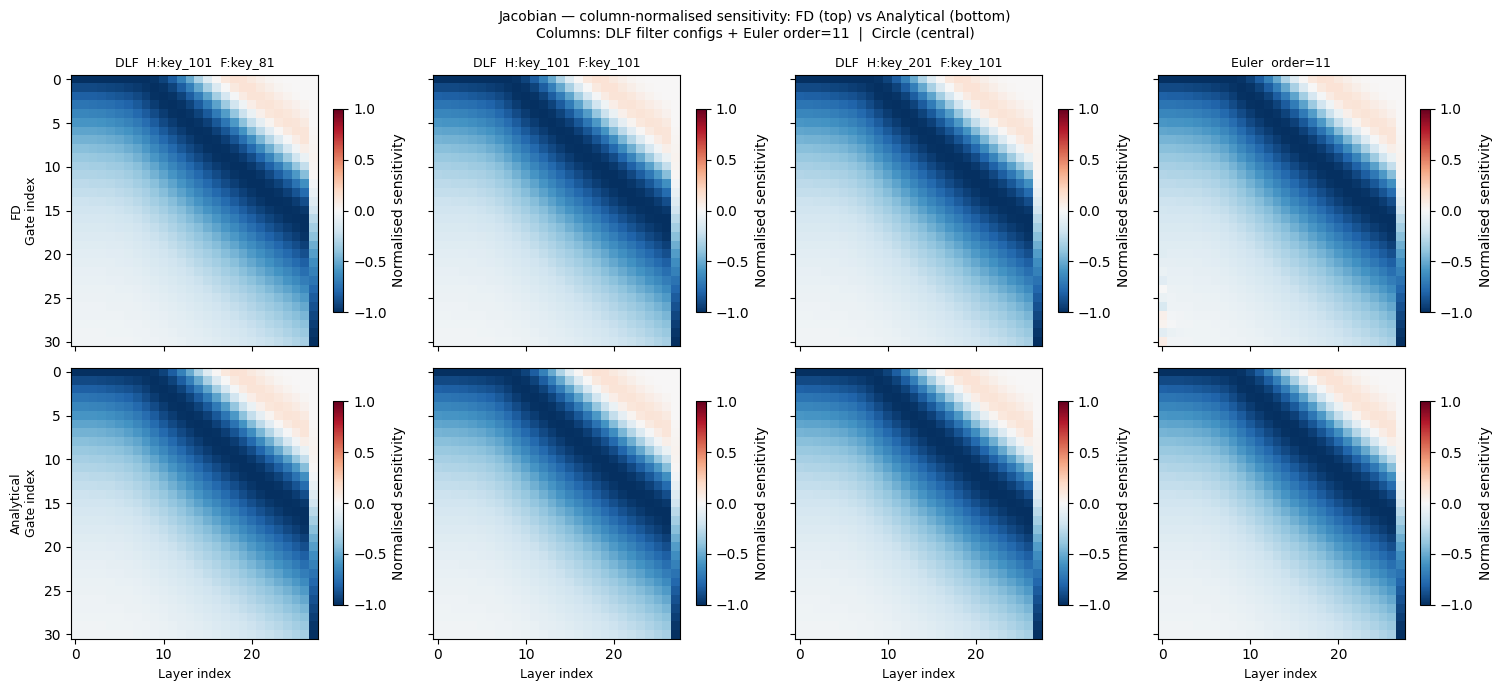

In [25]:

# ============================================================================
# Jacobian comparison: FD (top row) vs Analytical (bottom row)
# Columns: three DLF filter configs + Euler order=11
# ============================================================================
_dlf_configs = [
    ('DLF  H:key_101  F:key_81',  'key_101', 'key_81'),
    ('DLF  H:key_101  F:key_101', 'key_101', 'key_101'),
    ('DLF  H:key_201  F:key_101', 'key_201', 'key_101'),
]
_euler_label = 'Euler  order=11'
_best_nb = HAS_NUMBA   # use Numba if available

_J_fd_cfgs  = []   # list of (label, J)
_J_ana_cfgs = []   # list of (label, J)

print(f"Computing Jacobians for filter comparison ({_fwd_label}) ...")

for _cfg_label, _hf, _ff in _dlf_configs:
    print(f"  {_cfg_label} ...", end='', flush=True)
    _t0 = time.perf_counter()
    _jfd = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
                tx_geom=a, times=times, use_numba=_best_nb, use_cuda=False,
                fwd=_fwd_model, transform='dlf',
                hankel_filter=_hf, fourier_filter=_ff)
    _jana = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                             tx_geom=a, times=times, geometry=_geometry,
                             use_numba=_best_nb, **_ana_kwargs,
                             hankel_filter=_hf, fourier_filter=_ff)
    print(f"  {time.perf_counter() - _t0:.1f} s")
    _J_fd_cfgs.append((_cfg_label, _jfd))
    _J_ana_cfgs.append((_cfg_label, _jana))

# Euler column — FD and Analytical both supported
print(f"  {_euler_label} ...", end='', flush=True)
_t0 = time.perf_counter()
_jfd_euler = getJ(thicknesses=thicknesses, log_resistivities=log_resistivities,
                  tx_geom=a, times=times, use_numba=_best_nb, use_cuda=False,
                  fwd=_fwd_model, transform='euler', euler_order=11)
_jana_euler = getJ_analytical(thicknesses=thicknesses, log_resistivities=log_resistivities,
                               tx_geom=a, times=times, geometry=_geometry,
                               use_numba=_best_nb, **_ana_kwargs,
                               transform='euler', euler_order=11)
print(f"  {time.perf_counter() - _t0:.1f} s")
_J_fd_cfgs.append((_euler_label, _jfd_euler))
_J_ana_cfgs.append((_euler_label, _jana_euler))

_n_cfg = len(_J_fd_cfgs)   # 4 columns

fig, axes = plt.subplots(2, _n_cfg, figsize=(3.8 * _n_cfg, 7), sharey=True, sharex=True)

for col in range(_n_cfg):
    cfg_lbl, Jfd  = _J_fd_cfgs[col]
    _,        Jana = _J_ana_cfgs[col]

    # --- Top row: FD ---
    ax = axes[0, col]
    Jn_fd = Jfd / np.maximum(np.abs(Jfd).max(axis=0, keepdims=True), 1e-12)
    im = ax.imshow(Jn_fd, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    ax.set_title(cfg_lbl, fontsize=9)
    if col == 0:
        ax.set_ylabel('FD\nGate index', fontsize=9)
    plt.colorbar(im, ax=ax, shrink=0.75, label='Normalised sensitivity')

    # --- Bottom row: Analytical ---
    ax = axes[1, col]
    Jn_ana = Jana / np.maximum(np.abs(Jana).max(axis=0, keepdims=True), 1e-12)
    im2 = ax.imshow(Jn_ana, aspect='auto', cmap='RdBu_r', vmin=-1, vmax=1)
    plt.colorbar(im2, ax=ax, shrink=0.75, label='Normalised sensitivity')
    if col == 0:
        ax.set_ylabel('Analytical\nGate index', fontsize=9)
    ax.set_xlabel('Layer index', fontsize=9)

fig.suptitle(
    f'Jacobian — column-normalised sensitivity: FD (top) vs Analytical (bottom)\n'
    f'Columns: DLF filter configs + Euler order=11  |  {_fwd_label}',
    fontsize=10)
fig.tight_layout()
plt.show()


Computing Euler-Stehfest FD Jacobian for 'Circle (central)' (Numba) ...
Euler FD vs DLF FD:  max rel. error = 3.18e+00,  mean (non-zero) = 2.11e-02


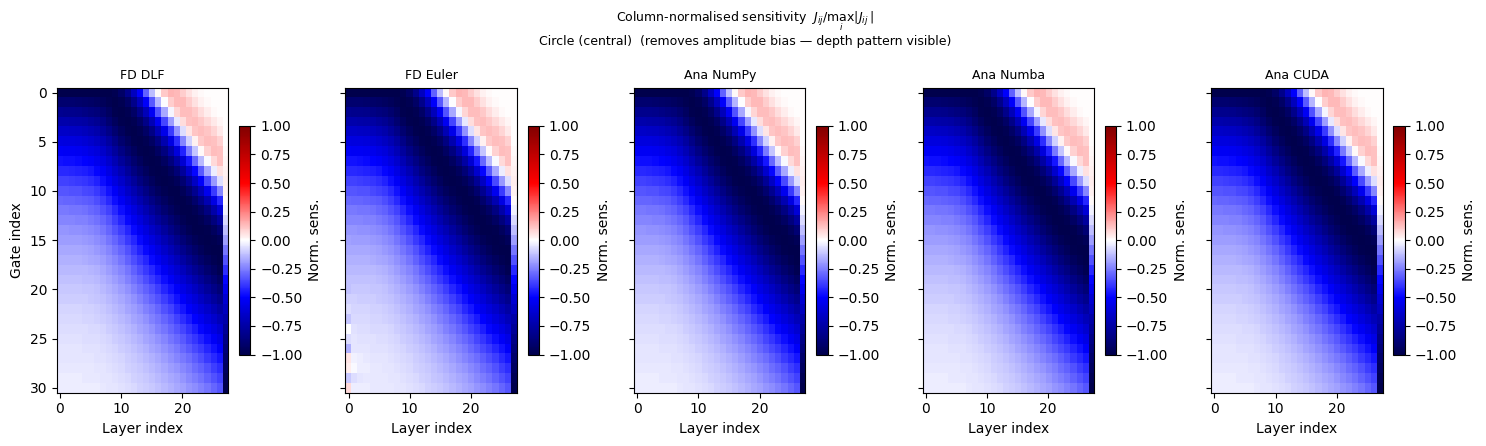


Half-space (last layer) sensitivity as % of total integrated sensitivity:
  FD DLF      : 32.2%
  FD Euler    : 32.2%
  Ana NumPy   : 32.2%
  Ana Numba   : 32.2%
  Ana CUDA    : 32.2%

Note: high half-space sensitivity is physically correct — all diffusing
current ultimately accumulates in the half-space, so late-time gates
(which dominate here) all carry sensitivity to its resistivity.


In [26]:

# ============================================================================
# Sensitivity comparison: column-normalised images, depth profile, Euler check
# ============================================================================
# For the Euler Jacobian we use the fastest available backend — the purpose
# here is accuracy comparison (Euler vs DLF), not timing.
_euler_nb  = HAS_NUMBA
_euler_gpu = HAS_CUDA and not HAS_NUMBA

print(f"Computing Euler-Stehfest FD Jacobian for '{_fwd_label}' "
      f"({'Numba' if _euler_nb else 'CUDA' if _euler_gpu else 'NumPy'}) ...")
J_fd_euler = getJ(
    thicknesses=thicknesses, log_resistivities=log_resistivities,
    tx_geom=a, times=times, use_numba=_euler_nb, use_cuda=_euler_gpu,
    fwd=_fwd_model, transform='euler', euler_order=11)

# Check consistency of Euler vs DLF FD
_denom_e = np.maximum(np.abs(J_fd_geo), 1e-30)
rel_err_euler = np.abs(J_fd_euler - J_fd_geo) / _denom_e
print(f"Euler FD vs DLF FD:  max rel. error = {rel_err_euler.max():.2e},  "
      f"mean (non-zero) = {rel_err_euler[np.abs(J_fd_geo) > 1e-10].mean():.2e}")

# Build comparison list (all geometries)
_cmp = [('FD DLF', J_fd_geo), ('FD Euler', J_fd_euler), ('Ana NumPy', J_ana)]
if HAS_NUMBA:
    _cmp.append(('Ana Numba', J_ana_nb))
if HAS_CUDA:
    _cmp.append(('Ana CUDA', J_ana_gpu))
n_cmp = len(_cmp)

N_lay     = J_fd_geo.shape[1]
th_arr    = np.asarray(thicknesses)
depth_top = np.concatenate([[0.0], np.cumsum(th_arr)])
depth_mid = depth_top[:-1] + th_arr / 2.0   # midpoints of all N layers, shape (N,)

# ---- Column-normalised sensitivity images ----
fig1, axes1 = plt.subplots(1, n_cmp, figsize=(3.0 * n_cmp, 4.5), sharey=True)
axes1 = np.atleast_1d(axes1)
for ax, (lbl, Jmat) in zip(axes1, _cmp):
    Jn = Jmat / np.maximum(np.abs(Jmat).max(axis=0, keepdims=True), 1e-30)
    im = ax.imshow(Jn, aspect='auto', cmap='seismic', vmin=-1, vmax=1)
    ax.set_title(lbl, fontsize=9)
    ax.set_xlabel('Layer index')
    plt.colorbar(im, ax=ax, shrink=0.75, label='Norm. sens.')
axes1[0].set_ylabel('Gate index')
fig1.suptitle(r'Column-normalised sensitivity  $J_{ij}/\max_i|J_{ij}|$'
              f'\n{_fwd_label}  (removes amplitude bias — depth pattern visible)',
              fontsize=9)
fig1.tight_layout()
plt.show()

# ---- Half-space fraction ----
print("\nHalf-space (last layer) sensitivity as % of total integrated sensitivity:")
for lbl, Jmat in _cmp:
    cs   = np.sqrt((Jmat ** 2).sum(axis=0))
    frac = cs[-1] / cs.sum() * 100
    print(f"  {lbl:12s}: {frac:.1f}%")
print("\nNote: high half-space sensitivity is physically correct — all diffusing\n"
      "current ultimately accumulates in the half-space, so late-time gates\n"
      "(which dominate here) all carry sensitivity to its resistivity.")
